# **Projet Sciences des données :**<br> Système intelligent de prévision des ventes en grande distribution

### Dataset : **Walmart Sales Forecast**

**Problématique :**<br>
Comment concevoir un système intelligent capable de produire des prévisions fiables et exploitables des ventes hebdomadaires  
par magasin et par département afin d'améliorer la prise de décision opérationnelle ?


**Objectif général :**<br>
Développer un modèle prédictif robuste permettant d’anticiper les ventes hebdomadaires avec un haut niveau de précision.

**Objectifs spécifiques :**
- Analyser les facteurs influençant les ventes
- Construire un pipeline de données fiable
- Tester plusieurs modèles de Machine Learning
- Évaluer les performances
- Déployer un prototype utilisable par les décideurs

## 1. Compréhension des données

### Chargement des données

In [90]:
# Importation des bibliothèques nécessaires
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [91]:
# Chargement des des données
features = pd.read_csv("Walmart/features.csv")
stores = pd.read_csv("Walmart/stores.csv")
train = pd.read_csv("Walmart/train.csv")
test = pd.read_csv("Walmart/test.csv")

display(features.head())
display(stores.head())
display(train.head())
display(test.head())

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


#### Description des variables

| Nom de la colonne	| Description |
|---|---|
| Âge	| Âge du demandeur en années |
| Revenus |	Revenu du demandeur (annuel) |
| Montant du prêt	| Montant total du prêt demandé par le demandeur |
| CréditScore	| Score de crédit représentant la solvabilité du demandeur	|
| Années d’expérience | Années totales d’expérience professionnelle |
| Genre	|	Genre du demandeur |
| Éducation |	Niveau d’éducation le plus élevé atteint par le candidat |
| Ville	| Ville de résidence du demandeur |
| Type d’emploi	| Type d’emploi (par exemple, salarié, travailleur indépendant) |
| Prêt approuvé	(variable cible) | Indique si le prêt a été approuvé (Oui/Non) |


##### Analyse structurelle des jeux de données

In [92]:
# Information sur les différents Datasets
print(features.info(),"\n")
print(stores.info(),"\n")
print(train.info(),"\n")
print(test.info(),"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 

### Fusion des jeux de données

In [93]:
# Datasets Features et Stores
stores_features = pd.merge(features, stores, on='Store', how='left') # Jointure gauche
stores_features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,B,118221
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,B,118221
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,B,118221
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,B,118221


In [94]:
# Datasets train et stores_features
df = pd.merge(train, stores_features, on=['Store', 'Date'], how='left')
df = df.drop(columns=['IsHoliday_y'])
df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [95]:
# Datasets test et stores_features
df_evaluation = pd.merge(test, stores_features, on=['Store', 'Date'], how='left')
df_evaluation.drop('IsHoliday_y', axis=1, inplace=True)
df_evaluation.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
df_evaluation.head()

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


###	Vérification des problèmes de qualité de données

In [96]:
# Vérification des doublons
df.duplicated().sum()

np.int64(0)

In [97]:
# Vérification des valeurs manquantes (en pourcentage)
(df.isnull().mean() * 100).round(2)

Store            0.00
Dept             0.00
Date             0.00
Weekly_Sales     0.00
IsHoliday        0.00
Temperature      0.00
Fuel_Price       0.00
MarkDown1       64.26
MarkDown2       73.61
MarkDown3       67.48
MarkDown4       67.98
MarkDown5       64.08
CPI              0.00
Unemployment     0.00
Type             0.00
Size             0.00
dtype: float64

In [98]:
# Séparation des variables numériques et catégorielles
num_col = df.select_dtypes(include=['int64', 'float64']).columns
cat_col = df.select_dtypes(exclude="number").columns

#cat_col = cat_col.drop('Date', errors='ignore') # isolation de la variable Date

In [99]:
# Vérification des valeurs aberrantes ou outliers

# Méthode de boxplot :
#df.boxplot(figsize=(16,5))
#plt.show()

# Méthode IQR :
Q1 = df[num_col].quantile(0.25)
Q3 = df[num_col].quantile(0.75)
IQR = Q3 - Q1
outliers = (df[num_col] < (Q1 - 1.5 * IQR)) | (df[num_col] > (Q3 + 1.5 * IQR))

outliers_count = outliers.sum() # compte les True par colonne
outliers_percent = (outliers.sum() / len(df)) * 100
print(outliers_percent.round(2))

Store           0.00
Dept            0.00
Weekly_Sales    8.43
Temperature     0.02
Fuel_Price      0.00
MarkDown1       2.30
MarkDown2       4.18
MarkDown3       4.43
MarkDown4       3.06
MarkDown5       1.85
CPI             0.00
Unemployment    7.62
Size            0.00
dtype: float64


In [100]:
# Vérification des incohérences
for col in df.columns:
    print(df[col].value_counts(dropna=False).sort_index(), "\n")

Store
1     10244
2     10238
3      9036
4     10272
5      8999
6     10211
7      9762
8      9895
9      8867
10    10315
11    10062
12     9705
13    10474
14    10040
15     9901
16     9443
17     9864
18     9859
19    10148
20    10214
21     9582
22     9688
23    10050
24    10228
25     9804
26     9854
27    10225
28    10113
29     9455
30     7156
31    10142
32    10202
33     6487
34    10224
35     9528
36     6222
37     7206
38     7362
39     9878
40    10017
41    10088
42     6953
43     6751
44     7169
45     9637
Name: count, dtype: int64 

Dept
1     6435
2     6435
3     6435
4     6435
5     6347
      ... 
95    6435
96    4854
97    6278
98    5836
99     862
Name: count, Length: 81, dtype: int64 

Date
2010-02-05    2955
2010-02-12    2956
2010-02-19    2977
2010-02-26    2951
2010-03-05    2944
              ... 
2012-09-28    2962
2012-10-05    2976
2012-10-12    2990
2012-10-19    2950
2012-10-26    2959
Name: count, Length: 143, dtype: int64 

Weekl

## **2. Préparer les données**

## 2.1. Nettoyage des données

##### Valeurs manquantes

In [101]:
# Imputation des Valeurs manquantes des varaibles MarkDown 1 à 5 par 0
cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[cols] = df[cols].fillna(0)

##### Incohérences

In [102]:
# Remplacement par 0 pour les Valeurs négatives de la variable Weekly_Sales
df['Weekly_Sales'] = np.where(df['Weekly_Sales'] < 0, 0, df['Weekly_Sales'])

In [103]:
# Remplacement par 0 pour les Valeurs négatives des variables MarkDown2 et MarkDown3
df['MarkDown2'] = np.where(df['MarkDown2'] < 0, 0, df['MarkDown2'])
df['MarkDown3'] = np.where(df['MarkDown3'] < 0, 0, df['MarkDown3'])

##### Valeurs aberrantes

In [104]:
# Pour les Valeurs aberrantes de Unemployment (7.62%), on peut choisir d'appliquer une Winsorisation.
lower = df['Unemployment'].quantile(0.10)
upper = df['Unemployment'].quantile(0.90)

df['Unemployment_winsor'] = df['Unemployment'].clip(lower, upper)   # Winsorisation appliquée
print(df[['Unemployment', 'Unemployment_winsor']].describe())       # vérification

df.drop('Unemployment', axis=1, inplace=True)
df.rename(columns={'Unemployment_winsor': 'Unemployment'}, inplace=True)

        Unemployment  Unemployment_winsor
count  421570.000000        421570.000000
mean        7.960289             7.814453
std         1.863296             1.168628
min         3.879000             5.965000
25%         6.891000             6.891000
50%         7.866000             7.866000
75%         8.572000             8.572000
max        14.313000             9.816000


## 2.2. Préparation des données

### Création de nouvelles variables (Feature Engineering)

In [105]:
# Variable Weekly_Sales_log : afin de  les Valeurs aberrantes de Weekly_Sales (8.43%) en applicant le logarithme
df['Weekly_Sales_log'] = np.log1p(df['Weekly_Sales'])

In [106]:
# Variables dérivées de Date
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week    # retourne le numéro de semaine ISO (1–52 ou 53)
#df['Day'] = df['Date'].dt.day
#df['DayOfWeek'] = df['Date'].dt.dayofweek     # 0 = lundi, 6 = dimanche
#df['DayOfYear'] = df['Date'].dt.dayofyear

df.head()

#for col in ['Year', 'Month', 'Week']:
#    print(df[col].value_counts(dropna=False).sort_index(),"\n")

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Type,Size,Unemployment,Weekly_Sales_log,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,A,151315,8.106,10.123647,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,A,151315,8.106,10.737277,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,A,151315,8.106,10.635773,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,A,151315,8.106,9.873262,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,A,151315,8.106,9.990990,2010,3,9


Dans la norme ISO :
La semaine 1 n’est pas forcément celle du 1er janvier, il s'agit de la première semaine qui contient un jeudi.
Conséquence :
- certaines dates de fin décembre peuvent appartenir à la semaine 1 de l’année suivante
- certaines dates de début janvier peuvent appartenir à la dernière semaine de l’année précédente

Les semaines ISO permettent :
- d’avoir des semaines complètes et cohérentes
- d’éviter les semaines coupées au début ou à la fin de l’année
- d’être compatible avec les standards internationaux

In [107]:
# Variable Flag indicant l'existence d'une promotion (Markdown 1 ou 2 ou 3 ou 4 ou 5) pour une semaine donnée
df['Flag'] = np.where(df[[col for col in df.columns if 'MarkDown' in col]].sum(axis=1) != 0, 1, 0)

df['Flag'].value_counts()

Flag
0    270138
1    151432
Name: count, dtype: int64

Mesure de performance en moins avec ce traitement

In [108]:
# Lag de la variable cible par Store & Dept pour les 1 à 4 semaines précédentes
df['Lag_1'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['Lag_2'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)
df['Lag_3'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(3)
df['Lag_4'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)

In [109]:
# Gestion des valeurs manquantes créées par les lags
Lags  = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4']
df[Lags] = df[Lags].fillna(0)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Weekly_Sales_log,Year,Month,Week,Flag,Lag_1,Lag_2,Lag_3,Lag_4
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,8.106,10.123647,2010,2,5,0,0.00,0.00,0.00,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,8.106,10.737277,2010,2,6,0,24924.50,0.00,0.00,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,8.106,10.635773,2010,2,7,0,46039.49,24924.50,0.00,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,8.106,9.873262,2010,2,8,0,41595.55,46039.49,24924.50,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,8.106,9.990990,2010,3,9,0,19403.54,41595.55,46039.49,24924.5


In [110]:
# Créer une variable Target encoding correspondant la moyenne par catégorie de store et de département pour la variable cible (ventes)

### Sélection des caractéristiques

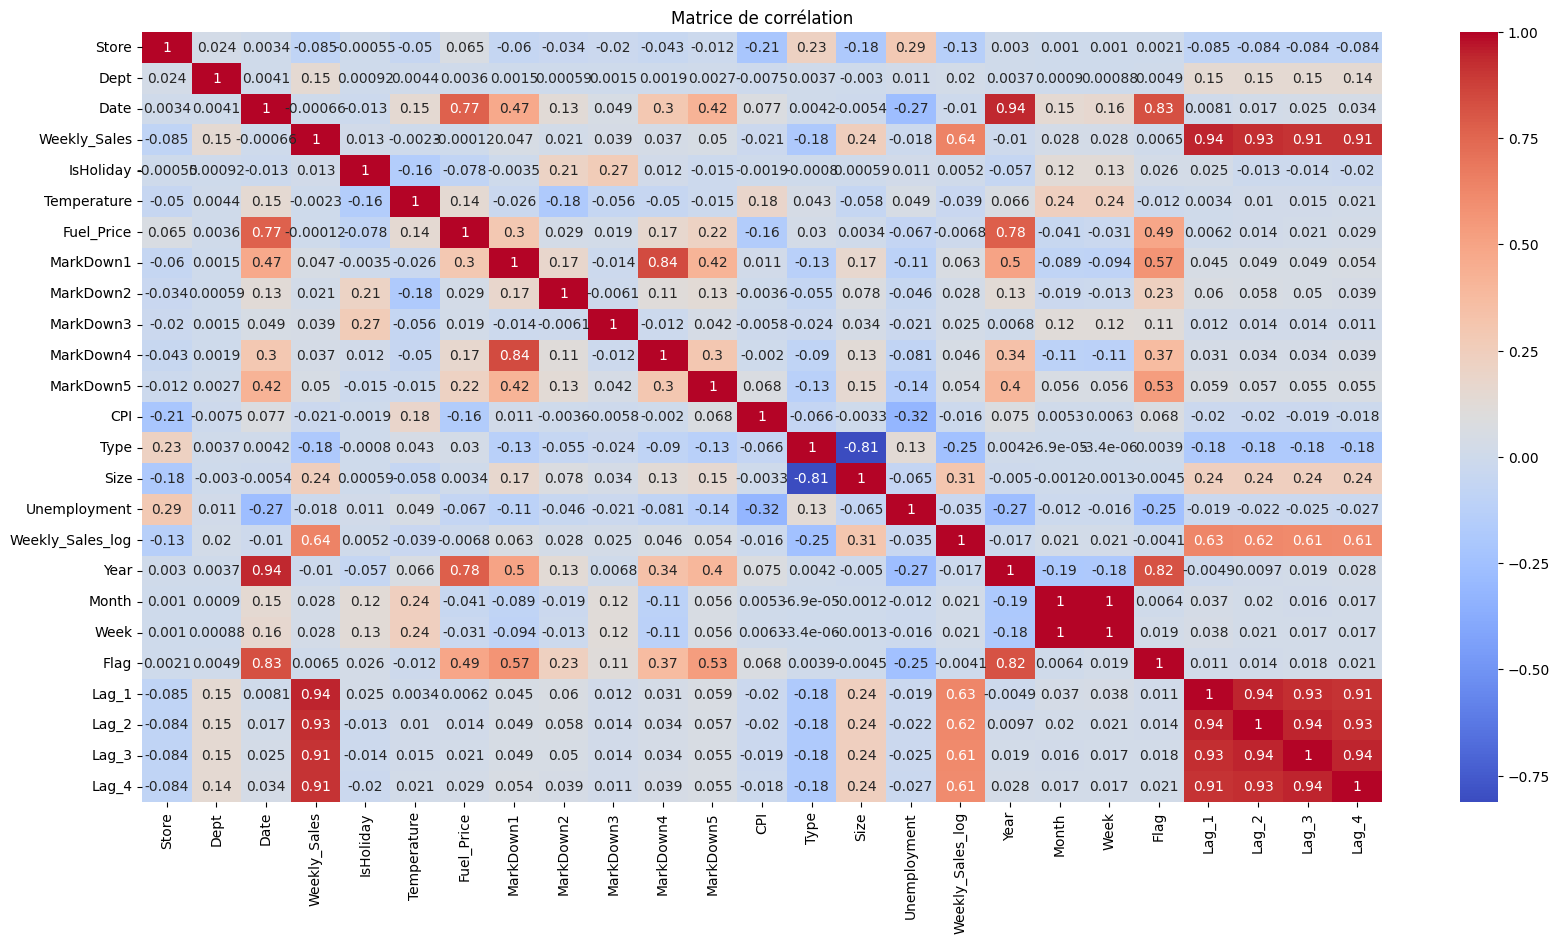

In [111]:
# Vérification de corrélation en prenant en compte les nouvelles variables créées
df_correlation = df.copy()

for col in df_correlation.select_dtypes(include=['object', 'category']).columns:
    df_correlation[col] = LabelEncoder().fit_transform(df_correlation[col].astype(str))

plt.figure(figsize=(20,10))
plt.title("Matrice de corrélation")
sns.heatmap(df_correlation.corr(), annot=True, cmap='coolwarm')
plt.show()

In [112]:
# Retrait des variables fortement correlées avant l'entrainement du modéle
df_clean = df.copy()
#df_clean = df_clean.drop(['Weekly_Sales', 'Date', 'Type', 'Month', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], axis=1)
df_clean = df_clean.drop(['Weekly_Sales', 'Date', 'Type', 'Month','Flag'], axis=1)

df_clean.head()

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Size,Unemployment,Weekly_Sales_log,Year,Week,Lag_1,Lag_2,Lag_3,Lag_4
0,1,1,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,151315,8.106,10.123647,2010,5,0.00,0.00,0.00,0.0
1,1,1,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,151315,8.106,10.737277,2010,6,24924.50,0.00,0.00,0.0
2,1,1,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,151315,8.106,10.635773,2010,7,46039.49,24924.50,0.00,0.0
3,1,1,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,151315,8.106,9.873262,2010,8,41595.55,46039.49,24924.50,0.0
4,1,1,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,151315,8.106,9.990990,2010,9,19403.54,41595.55,46039.49,24924.5


### Transformation des données

In [113]:
# Encodage des variables catégorielles

df_clean['Store'] = df_clean['Store'].astype('category')
df_clean['Dept'] = df_clean['Dept'].astype('category')

#df = pd.get_dummies(df_clean, columns=['IsHoliday', 'Type'], dtype=int)
cols_to_encode = ['Store', 'Dept', 'IsHoliday']

encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(df_clean[cols_to_encode])

df_encoded = pd.DataFrame(
    X,
    columns=encoder.get_feature_names_out(cols_to_encode),
    index=df_clean.index
)

df_clean = df_clean.drop(columns=cols_to_encode)
df_clean = pd.concat([df_clean, df_encoded], axis=1)

df_clean.head()

,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Size,Unemployment,...,Dept_92,Dept_93,Dept_94,Dept_95,Dept_96,Dept_97,Dept_98,Dept_99,IsHoliday_False,IsHoliday_True
0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,151315,8.106,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,151315,8.106,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,151315,8.106,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,151315,8.106,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,151315,8.106,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [114]:
# Standardisation des variables numériques

# Transformer Week en variables trigonométriques avant la standardisation pour mieux capturer la nature cyclique de la variable temporelle :
df_clean['Week_sin'] = np.sin(2 * np.pi * df_clean['Week']/52)
df_clean['Week_cos'] = np.cos(2 * np.pi * df_clean['Week']/52)

cols_to_scale = ['Year', 'Week_sin', 'Week_cos','Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

scaler = StandardScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

df_clean.head()

,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Size,Unemployment,...,Dept_94,Dept_95,Dept_96,Dept_97,Dept_98,Dept_99,IsHoliday_False,IsHoliday_True,Week_sin,Week_cos
0,-0.963798,-1.720834,0.0,0.0,0.0,0.0,0.0,1.018774,0.239209,0.249478,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.755739,1.315527
1,-1.169783,-1.773177,0.0,0.0,0.0,0.0,0.0,1.022498,0.239209,0.249478,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.886845,1.206663
2,-1.092810,-1.847330,0.0,0.0,0.0,0.0,0.0,1.023697,0.239209,0.249478,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.004614,1.081843
3,-0.729625,-1.744825,0.0,0.0,0.0,0.0,0.0,1.024476,0.239209,0.249478,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.107329,0.942887
4,-0.736672,-1.605243,0.0,0.0,0.0,0.0,0.0,1.025255,0.239209,0.249478,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.193491,0.791823


In [115]:
# Construction du jeu d’entraînement et de test
from sklearn.model_selection import train_test_split

# 1. Séparation des variables explicatives de la variable cible
X = df_clean.drop('Weekly_Sales_log', axis=1)
y = df_clean['Weekly_Sales_log']

# 2. séparation Train + Temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# 3. séparation Validation et Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(295099, 146) (63235, 146) (63236, 146)


## **3. Modéliser**

### Implementation d'un modèle baseline : *Régression linéaire*

In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Définition du modèle
model = LinearRegression()

# Entrainement du modèle
model.fit(X_train, y_train)

# Prédiction sur le jeu de validation
y_predV = model.predict(X_val)

In [117]:
# Évaluation du modèle
mse = mean_squared_error(y_val, y_predV)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_predV)
r2 = r2_score(y_val, y_predV)

print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")
print(f"R2 : {r2}")

MSE : 1.2542767199016367
RMSE : 1.1199449628895326
MAE : 0.7012748486308965
R2 : 0.7096591337860307


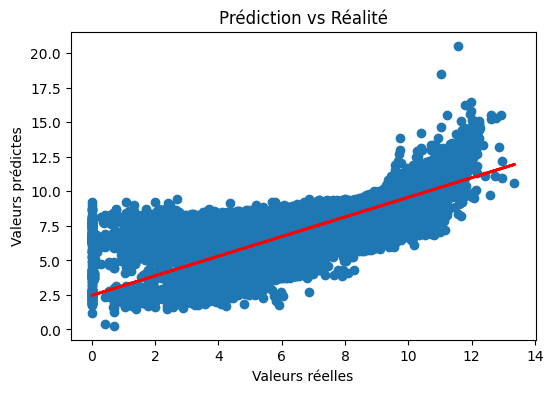

In [118]:
# Visualisation de la relation entre les valeurs réelles et les valeurs prédictes
reg = LinearRegression()
reg.fit(y_val.values.reshape(-1,1), y_predV)

plt.figure(figsize=(6,4))
plt.scatter(y_val, y_predV)
plt.plot(y_val, reg.predict(y_val.values.reshape(-1,1)), 'r', lw=2)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédictes")
plt.title("Prédiction vs Réalité")
plt.show()  # Le modèle est bon si les points seront près de la diagonale.

##### ***Conclusion de la modélisation de base***

| Prétraitement appliqué | Métrique de performance |
|---|---|
| Prétraitement de base (gestion des valeurs manquantes, valeurs<br> aberrantes et incohérences, encodage et standardisation) | R2 : 0.6542262936006564 |    
| Considération des variables Store et Dept comme catégorielles | R2 : 0.657956646825311 |  
| Transformation de la variable Week en sin et cos avant la standardisation<br> pour mieux capturer la nature cyclique de la variable temporelle | R2 : 0.6586010028882554 |  
| Application du logarithme sur la variable Weekly_Sales | R2 : 0.6784668121059209 |   
| Utilisation des Lags (ventes des semaines précédentes) | R2 : 0.7094775671224884 |

In [119]:
y_test_original = np.expm1(y_val)
y_pred_original = np.expm1(y_predV)

rmse_real = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_real = mean_absolute_error(y_test_original, y_pred_original)

print(rmse_real, mae_real)
# MAE ≈ 29 518 : En moyenne, le modèle se trompe d’environ 29 500 $ par semaine

3352196.8532724967 29518.060839471902


En résumé, le modèle :
- prédit correctement les ventes normales
- mais se trompe fortement sur les périodes exceptionnelles : promotions (MarkDown), fêtes (Noël, Black Friday), pics saisonniers